# 3D Firefly view of a BRAHMA subhalo

This notebook loads the same postprocessed subhalo particle data used by `bh_2dplot.py` and registers gas, dark matter, stars, and black holes with Firefly. Coordinates are recentered on the postprocessed subhalo position, wrapped across periodic box boundaries, and converted to physical kpc.

## 1. Imports and snapshot selection

This notebook reproduces the case in `bh_2dplot_snap25_sub683_xy_bg0_auto_inferno_adaptive_36022120.pdf`: snapshot 25, subhalo 683, the `xy` view, gas background (`bg_ptype=0`), automatic box size, and adaptive smoothing. Firefly shows the same centered physical-kpc particle data in 3D.

In [1]:
import numpy as np

from cosmo_sim_tools import brahma
from cosmo_sim_tools.arepo_tools import arepo_package as arepo
from firefly.data_reader import ParticleGroup, Reader

basePath = '/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/SM5_DFD_3_TNG'
snap = 25
subhalo_index = 683

snapshots, redshifts = arepo.get_snapshot_redshift_correspondence(basePath)
desired_redshift = float(redshifts[list(snapshots).index(snap)])
print(f'snapshot {snap} -> z = {desired_redshift:.4f}; subhalo {subhalo_index}')

snapshot 25 -> z = 0.9973; subhalo 683


## 2. Load the postprocessed subhalo data

The subhalo position is returned as an array when `SubhaloPos` is the only requested field. Coordinates are recentered on the subhalo, wrapped across periodic boundaries, and converted to physical kpc.

In [2]:
header = brahma.groupcat.loadHeader(basePath, snap)
h = float(header['HubbleParam'])
boxsize = float(header['BoxSize'])
scale_factor = float(header.get('Time', 1.0))
subhalos = brahma.groupcat.loadSubhalos_postprocessed(
    basePath, snap, fields=['SubhaloPos']
)
center = np.asarray(subhalos[subhalo_index], dtype=np.float64)


def load_subhalo_field(field, particle_type):
    try:
        result = arepo.get_particle_property_within_postprocessed_groups(
            basePath,
            particle_property=[field],
            p_type=particle_type,
            desired_redshift=desired_redshift,
            subhalo_index=subhalo_index,
            group_type='subhalo',
            store_all_offsets=0,
        )[0]
    except Exception as exc:
        if 'does not have field' in str(exc):
            print(f'p_type={particle_type}: skipping unavailable field {field}')
            return None
        raise
    if result is None or len(result) == 0:
        return None
    return np.asarray(result)


def recenter_coordinates(coordinates):
    displacement = np.asarray(coordinates, dtype=np.float64) - center
    displacement -= boxsize * np.round(displacement / boxsize)
    return displacement * scale_factor / h

print(f'h={h:.4f}, scale factor={scale_factor:.4f}, box size={boxsize:.2f} ckpc/h')

h=0.6771, scale factor=0.5007, box size=12500.00 ckpc/h


## 3. Define the particle groups

Each tuple is `(Arepo particle type, display name, RGBA color, fields to load)`. Arepo uses type 0 for gas, 1 for dark matter, 4 for stars, and 5 for black holes.

In [3]:
groups = [  # (particle_type, display_name, color, fields_to_load)
    (0, 'gas', [0.2, 0.6, 1.0, 1.0],
     ['Masses', 'Density', 'Temperature', 'StarFormationRate']),
    (1, 'DM', [0.45, 0.45, 0.45, 1.0], ['Masses']),
    (4, 'stars', [1.0, 0.8, 0.2, 1.0],
     ['Masses', 'GFM_StellarFormationTime', 'GFM_Metallicity']),
    (5, 'BHs', [1.0, 0.15, 0.1, 1.0], ['BH_Mass', 'BH_Mdot']),
]

data = {}
for particle_type, name, color, field_names in groups:
    coordinates = load_subhalo_field('Coordinates', particle_type)
    if coordinates is None:
        print(f'{name}: no particles in this subhalo')
        continue

    component = {'Coordinates': recenter_coordinates(coordinates)}
    for field_name in field_names:
        values = load_subhalo_field(field_name, particle_type)
        if values is not None and len(values) == len(coordinates):
            values = np.asarray(values, dtype=np.float64).ravel()
            if field_name in {'Masses', 'BH_Mass'}:
                values = values * 1e10 / h
            component[field_name] = values
    data[particle_type] = component
    print(f'{name}: {len(coordinates):,} particles')

p_type=0: skipping unavailable field Temperature
gas: 127,518 particles
p_type=1: skipping unavailable field Masses
DM: 272,894 particles
stars: 129,981 particles
BHs: 129 particles


## 4. Register groups with Firefly

Only fields that are available and have the same length as the coordinates are sent to Firefly. The particle positions remain centered physical-kpc coordinates.

In [4]:
reader = Reader()

for particle_type, name, color, requested_fields in groups:
    component = data.get(particle_type)
    if component is None:
        continue

    available_fields = [
        field_name
        for field_name in requested_fields
        if field_name in component
    ]
    field_arrays = [component[field_name] for field_name in available_fields]
    rgba_colors = np.tile(
        np.asarray(color, dtype=np.float32),
        (len(component['Coordinates']), 1),
    )

    reader.addParticleGroup(
        ParticleGroup(
            name,
            component['Coordinates'],
            field_arrays=field_arrays,
            field_names=available_fields,
            rgba_colors=rgba_colors,
            decimation_factor=1,
        )
    )

print('Firefly groups registered.')

datadir is None, defaulting to /blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly/static/data/Data
Make sure each field_array (3) has a field_filter_flag (0), assuming True.
Make sure each field_array (3) has a field_colormap_flag (0), assuming True.
Make sure each field_array (3) has a field_radius_flag (0), assuming False.
Make sure each field_array (3) has a field_filter_flag (0), assuming True.
Make sure each field_array (3) has a field_colormap_flag (0), assuming True.
Make sure each field_array (3) has a field_radius_flag (0), assuming False.
Make sure each field_array (2) has a field_filter_flag (0), assuming True.
Make sure each field_array (2) has a field_colormap_flag (0), assuming True.
Make sure each field_array (2) has a field_radius_flag (0), assuming False.
Firefly groups registered.


## 5. Start the interactive 3D viewer

Run this cell last. Firefly will start its local server; open the URL printed by the cell if it does not open automatically.

In [ ]:
from firefly.server import spawnFireflyServer, quitAllFireflyServers

port = 5500
process = spawnFireflyServer(port, method='flask')
url = f'http://localhost:{port:d}/combined'
print(f'Firefly server started: {url}')

/blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event


Waiting up to 10 seconds for background Firefly server to start......

/blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event
 * Restarting with stat


Launching Firefly at: http://localhost:5500
from directory /blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly
...

/blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event


Launching Firefly at: http://localhost:5500
from directory /blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly
.done! Your server is available at - http://localhost:5500
Firefly server started: http://localhost:5500/combined


======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= sid eJl7_ZcN6-_x4O0lAAAB disconnected from room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in

In [5]:
from IPython.display import IFrame, display

display(IFrame(src=url, width=1000, height=650))

Wait until the viewer appears and connects, then run the next cell to send the particle data.

In [6]:
import time

print('Waiting 10 seconds for the Firefly viewer to connect...')
time.sleep(10)
reader.sendDataViaFlask(port=port)
print(f'Firefly data sent: {url}')

Waiting 10 seconds for the Firefly viewer to connect...
gas - 127518/127518 particles - 3 tracked fields
DM - 272894/272894 particles - 0 tracked fields
stars - 129981/129981 particles - 3 tracked fields
BHs - 129/129 particles - 2 tracked fields
Posting data on port 5500...======= receiving data from server ...
======= size of data 52592814
======= showing loader
======= sending data to viewer ...
/blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly/static/data/Data/Datagas000.json 11220799
/blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly/static/data/Data/Datagas001.json 3032950
/blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly/static/data/Data/DataDM000.json 8389187
/blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/site-packages/firefly/static/data/Data/DataDM001.json 8518168
/blue/lblecha/pranavsatheesh/.conda/envs/wandering-bh/lib/python3.10/si

## 6. Retrieve selected particles and plot them

Select particles in Firefly, then run the next cell.

In [ ]:
import requests
import matplotlib.pyplot as plt
%matplotlib inline


In [19]:

response = requests.get(
    f'http://localhost:{port:d}/get_selected_data',
    params={'waitTime': 60},
)
response.raise_for_status()
selection = response.json()

bh_selection = selection.get('BHs', {})
flat_coordinates = bh_selection.get('Coordinates_flat', [])
coordinate_values = np.asarray(flat_coordinates, dtype=float)
usable_values = coordinate_values.size - coordinate_values.size % 3
bh_coordinates = coordinate_values[:usable_values].reshape(-1, 3)
bh_masses = np.asarray(bh_selection.get('BH_Mass', []), dtype=float).ravel()
bh_masses = bh_masses[:len(bh_coordinates)]

valid_masses = np.isfinite(bh_masses) & (bh_masses > 0)
plot_coordinates = bh_coordinates[valid_masses]
plot_masses = bh_masses[valid_masses]

print(f'Selected BHs: {len(bh_coordinates):,}')
print(f'BHs with valid masses: {len(plot_masses):,}')

======= received request for selected data from user
======= gettings selected data, waiting 60s
Selected BHs: 48
BHs with valid masses: 48


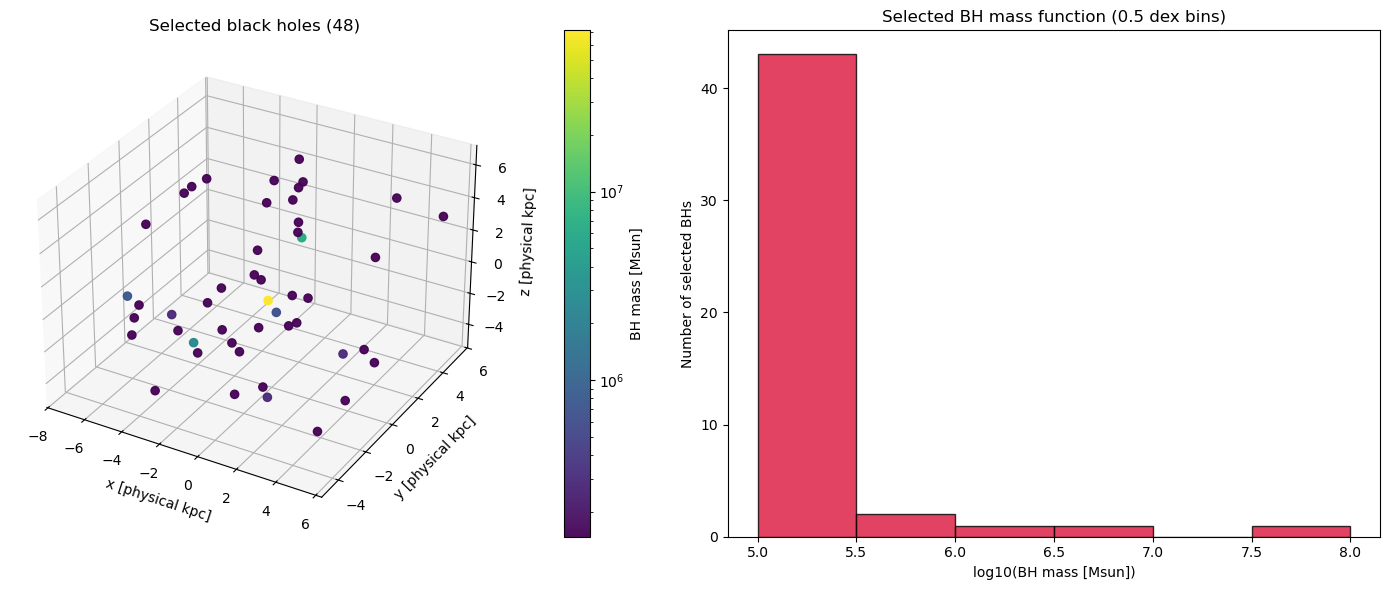

In [20]:
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(1, 2, 1, projection='3d')
mass_ax = fig.add_subplot(1, 2, 2)

if len(plot_coordinates):
    mass_norm = mcolors.LogNorm(vmin=plot_masses.min(), vmax=plot_masses.max())
    scatter = ax.scatter(
        plot_coordinates[:, 0], plot_coordinates[:, 1], plot_coordinates[:, 2],
        c=plot_masses, cmap='viridis', norm=mass_norm,
        s=35, alpha=0.95,
    )
    fig.colorbar(scatter, ax=ax, pad=0.1, label='BH mass [Msun]')
    ax.set_xlabel('x [physical kpc]')
    ax.set_ylabel('y [physical kpc]')
    ax.set_zlabel('z [physical kpc]')
    ax.set_title(f'Selected black holes ({len(plot_coordinates):,})')
else:
    ax.text2D(0.5, 0.5, 'No BHs with valid masses', transform=ax.transAxes, ha='center')

if len(plot_masses):
    log_masses = np.log10(plot_masses)
    bin_width = 0.5
    lower = np.floor(log_masses.min() / bin_width) * bin_width
    upper = np.ceil(log_masses.max() / bin_width) * bin_width
    if lower == upper:
        upper = lower + bin_width
    bins = np.arange(lower, upper + bin_width, bin_width)
    mass_ax.hist(log_masses, bins=bins, color='crimson', alpha=0.8, edgecolor='black')
    mass_ax.set_xlabel('log10(BH mass [Msun])')
    mass_ax.set_ylabel('Number of selected BHs')
    mass_ax.set_title(f'Selected BH mass function ({bin_width:.1f} dex bins)')
else:
    mass_ax.text(0.5, 0.5, 'No BH masses selected', ha='center', va='center', transform=mass_ax.transAxes)

plt.tight_layout()
plt.show()

## 7. Stop the Firefly server

Run this cell when you are finished with the viewer.

In [21]:
return_code = quitAllFireflyServers()
print(f'Firefly servers stopped: {return_code}')

Server output:
--------------
Firefly servers stopped: 15
